<a href="https://colab.research.google.com/github/nharri64/ECGR-4105/blob/Homeworks-and-datasets/Noah_Harris_801353171_HW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression, Ridge

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [30]:
uploaded = files.upload()

Saving Cancer.csv to Cancer (1).csv


In [31]:
uploaded = files.upload()

Saving Housing.csv to Housing (1).csv


In [32]:
# Problem 1 - SVM Cancer Classification

In [33]:
cancer = pd.read_csv('/content/Cancer.csv')

cancer = cancer.drop(
    columns=['id', 'Unnamed: 32'],
    errors='ignore'
)

cancer['diagnosis'] = cancer['diagnosis'].map({
    'M': 1,
    'B': 0
})

X_c = cancer.drop(columns=['diagnosis'])
y_c = cancer['diagnosis']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c,
    test_size=0.20,
    random_state=42,
    stratify=y_c
)

scaler_c = StandardScaler()

X_train_c = scaler_c.fit_transform(X_train_c)
X_test_c = scaler_c.transform(X_test_c)

print("Total samples:", len(cancer))
print("Input features:", X_c.shape[1])
print("Training samples:", len(y_train_c))
print("Testing samples:", len(y_test_c))

Total samples: 569
Input features: 30
Training samples: 455
Testing samples: 114


In [34]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']

svm_results = []
svm_models = {}

for kernel in kernels:
    model = SVC(
        kernel=kernel,
        C=1.0,
        gamma='scale',
        random_state=42
    )

    model.fit(X_train_c, y_train_c)
    predictions = model.predict(X_test_c)

    svm_models[kernel] = model

    svm_results.append({
        'Kernel': kernel,
        'Accuracy': accuracy_score(y_test_c, predictions),
        'Precision': precision_score(y_test_c, predictions),
        'Recall': recall_score(y_test_c, predictions),
        'F1 Score': f1_score(y_test_c, predictions)
    })

svm_results_df = pd.DataFrame(svm_results)

display(svm_results_df.round(4))

,Kernel,Accuracy,Precision,Recall,F1 Score
0,linear,0.9649,1.0000,0.9048,0.9500
1,rbf,0.9737,1.0000,0.9286,0.9630
2,poly,0.8860,1.0000,0.6905,0.8169
3,sigmoid,0.9474,0.9737,0.8810,0.9250


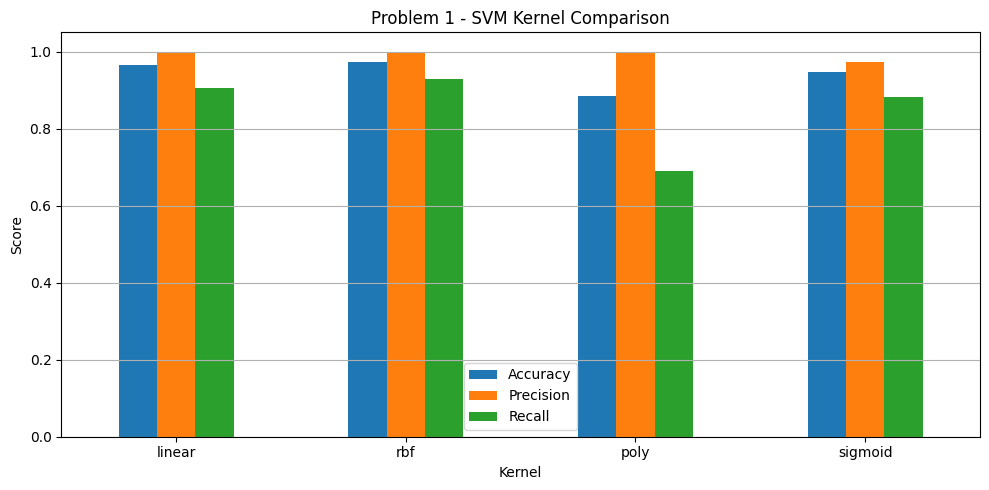

In [35]:
svm_results_df.set_index('Kernel')[
    ['Accuracy', 'Precision', 'Recall']
].plot(kind='bar', figsize=(10, 5))

plt.title('Problem 1 - SVM Kernel Comparison')
plt.ylabel('Score')
plt.xlabel('Kernel')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

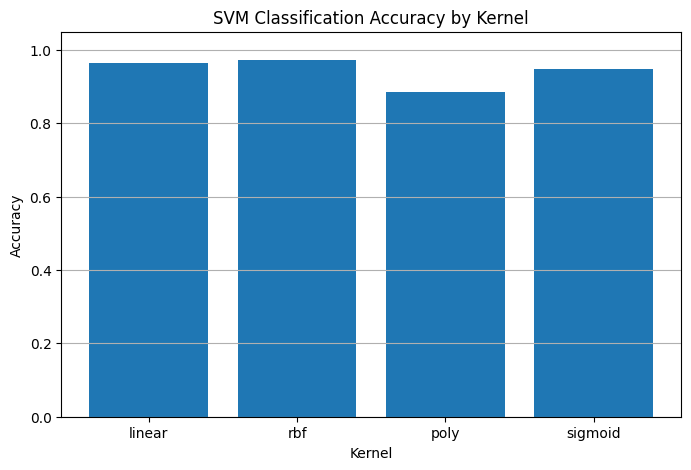

In [36]:
plt.figure(figsize=(8, 5))

plt.bar(
    svm_results_df['Kernel'],
    svm_results_df['Accuracy']
)

plt.title('SVM Classification Accuracy by Kernel')
plt.xlabel('Kernel')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.grid(axis='y')
plt.show()

In [37]:
hw3_results = {
    'Model': 'HW3 Logistic Regression',
    'Accuracy': 0.9737,
    'Precision': 0.9756,
    'Recall': 0.9524,
    'F1 Score': 0.9639
}

comparison_p1 = svm_results_df.copy()
comparison_p1.insert(
    0, 'Model',
    'SVM - ' + comparison_p1['Kernel']
)

comparison_p1 = comparison_p1.drop(columns=['Kernel'])

comparison_p1 = pd.concat([
    pd.DataFrame([hw3_results]),
    comparison_p1
], ignore_index=True)

display(comparison_p1.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,HW3 Logistic Regression,0.9737,0.9756,0.9524,0.9639
1,SVM - linear,0.9649,1.0000,0.9048,0.9500
2,SVM - rbf,0.9737,1.0000,0.9286,0.9630
3,SVM - poly,0.8860,1.0000,0.6905,0.8169
4,SVM - sigmoid,0.9474,0.9737,0.8810,0.9250


Best kernel by accuracy: rbf


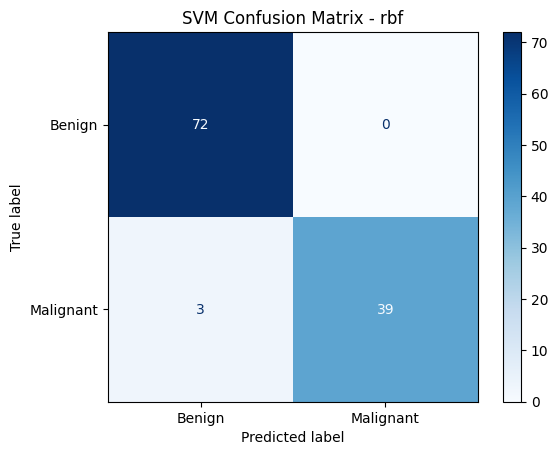

In [38]:
best_kernel = svm_results_df.loc[
    svm_results_df['Accuracy'].idxmax(),
    'Kernel'
]

best_model = svm_models[best_kernel]
best_predictions = best_model.predict(X_test_c)

print("Best kernel by accuracy:", best_kernel)

cm = confusion_matrix(y_test_c, best_predictions)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Benign', 'Malignant']
).plot(cmap='Blues')

plt.title(f'SVM Confusion Matrix - {best_kernel}')
plt.show()

In [39]:
# Problem 2 - SVR Housing Price Prediction

In [40]:
import os

print("CSV files available:")
for filename in os.listdir('/content'):
    if filename.lower().endswith('.csv'):
        print(filename)

CSV files available:
Cancer (1).csv
Cancer.csv
Housing.csv
Housing (1).csv


In [41]:
housing = pd.read_csv('/content/Housing.csv')

print("Dataset shape:", housing.shape)
print("Columns:")
print(housing.columns.tolist())

display(housing.head())

Dataset shape: (545, 13)
Columns:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [42]:
features = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'parking',
    'prefarea'
]

X_h = housing[features].copy()
y_h = housing['price']

# Convert yes/no columns to 1/0
yes_no_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in yes_no_columns:
    X_h[col] = X_h[col].map({'yes': 1, 'no': 0})

print("Missing input values:", X_h.isna().sum().sum())
print("Number of input features:", X_h.shape[1])

Missing input values: 0
Number of input features: 11


In [43]:
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_h, y_h,
    test_size=0.20,
    random_state=42
)

x_scaler_h = StandardScaler()
y_scaler_h = StandardScaler()

X_train_h = x_scaler_h.fit_transform(X_train_h)
X_test_h = x_scaler_h.transform(X_test_h)

y_train_scaled = y_scaler_h.fit_transform(
    y_train_h.to_numpy().reshape(-1, 1)
).ravel()

print("Training samples:", len(y_train_h))
print("Testing samples:", len(y_test_h))

Training samples: 436
Testing samples: 109


In [44]:
svr_kernels = ['linear', 'rbf', 'poly', 'sigmoid']

svr_results = []
svr_predictions = {}

for kernel in svr_kernels:
    model = SVR(
        kernel=kernel,
        C=1.0,
        epsilon=0.1,
        gamma='scale'
    )

    model.fit(X_train_h, y_train_scaled)

    predicted_scaled = model.predict(X_test_h)

    predictions = y_scaler_h.inverse_transform(
        predicted_scaled.reshape(-1, 1)
    ).ravel()

    svr_predictions[kernel] = predictions

    svr_results.append({
        'Kernel': kernel,
        'MAE': mean_absolute_error(y_test_h, predictions),
        'RMSE': np.sqrt(mean_squared_error(y_test_h, predictions)),
        'R2': r2_score(y_test_h, predictions)
    })

svr_results_df = pd.DataFrame(svr_results)

display(svr_results_df.round(4))

,Kernel,MAE,RMSE,R2
0,linear,1.000478e+06,1.389562e+06,0.6180
1,rbf,1.049355e+06,1.427320e+06,0.5970
2,poly,1.090739e+06,1.522343e+06,0.5415
3,sigmoid,2.607715e+06,4.007237e+06,-2.1769


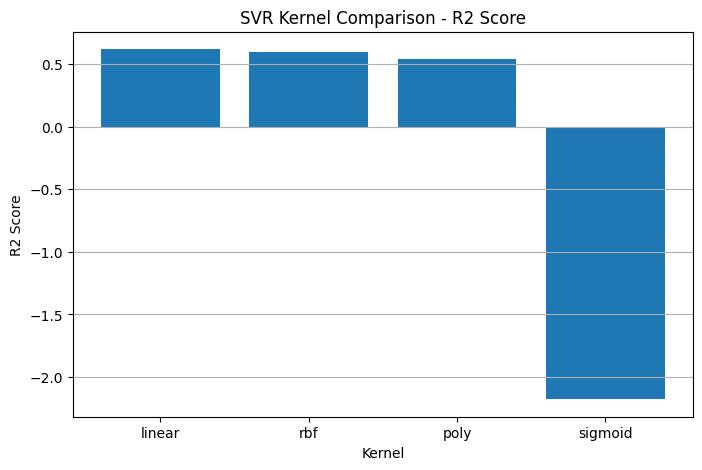

In [45]:
plt.figure(figsize=(8, 5))

plt.bar(
    svr_results_df['Kernel'],
    svr_results_df['R2']
)

plt.title('SVR Kernel Comparison - R2 Score')
plt.xlabel('Kernel')
plt.ylabel('R2 Score')
plt.grid(axis='y')
plt.show()

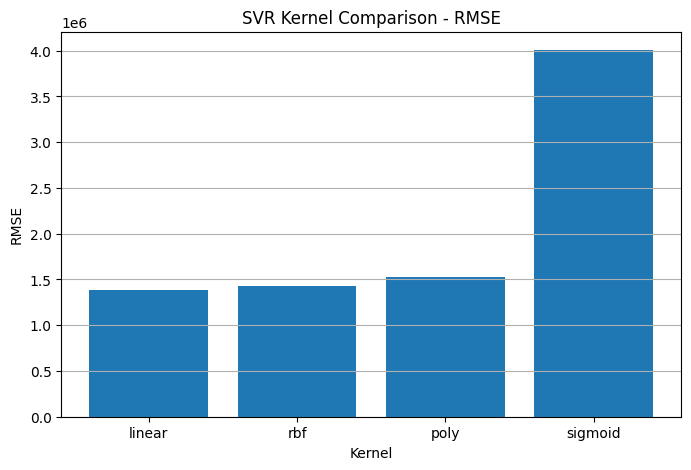

In [46]:
plt.figure(figsize=(8, 5))

plt.bar(
    svr_results_df['Kernel'],
    svr_results_df['RMSE']
)

plt.title('SVR Kernel Comparison - RMSE')
plt.xlabel('Kernel')
plt.ylabel('RMSE')
plt.grid(axis='y')
plt.show()

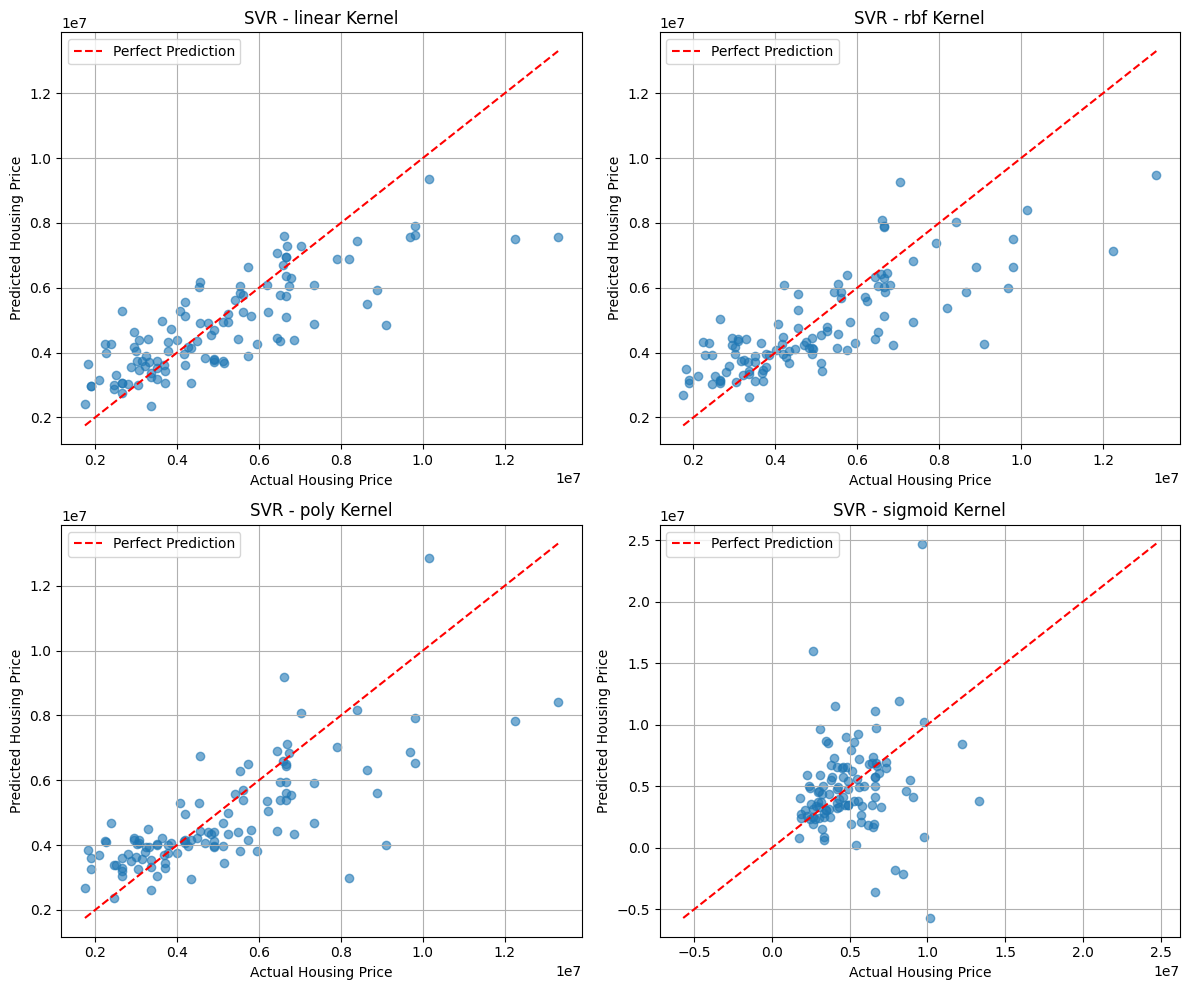

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, kernel in zip(axes.flat, svr_kernels):
    predictions = svr_predictions[kernel]

    ax.scatter(
        y_test_h,
        predictions,
        alpha=0.6
    )

    low = min(y_test_h.min(), predictions.min())
    high = max(y_test_h.max(), predictions.max())

    ax.plot(
        [low, high],
        [low, high],
        'r--',
        label='Perfect Prediction'
    )

    ax.set_title(f'SVR - {kernel} Kernel')
    ax.set_xlabel('Actual Housing Price')
    ax.set_ylabel('Predicted Housing Price')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [48]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_h, y_train_scaled)

ridge_scaled = ridge_model.predict(X_test_h)

ridge_predictions = y_scaler_h.inverse_transform(
    ridge_scaled.reshape(-1, 1)
).ravel()

ridge_results = {
    'Model': 'Ridge Regression (L2)',
    'MAE': mean_absolute_error(y_test_h, ridge_predictions),
    'RMSE': np.sqrt(mean_squared_error(y_test_h, ridge_predictions)),
    'R2': r2_score(y_test_h, ridge_predictions)
}

comparison_p2 = svr_results_df.copy()
comparison_p2.insert(
    0, 'Model',
    'SVR - ' + comparison_p2['Kernel']
)

comparison_p2 = comparison_p2.drop(columns=['Kernel'])

comparison_p2 = pd.concat([
    pd.DataFrame([ridge_results]),
    comparison_p2
], ignore_index=True)

display(comparison_p2.round(4))

,Model,MAE,RMSE,R2
0,Ridge Regression (L2),9.791469e+05,1.342156e+06,0.6436
1,SVR - linear,1.000478e+06,1.389562e+06,0.6180
2,SVR - rbf,1.049355e+06,1.427320e+06,0.5970
3,SVR - poly,1.090739e+06,1.522343e+06,0.5415
4,SVR - sigmoid,2.607715e+06,4.007237e+06,-2.1769


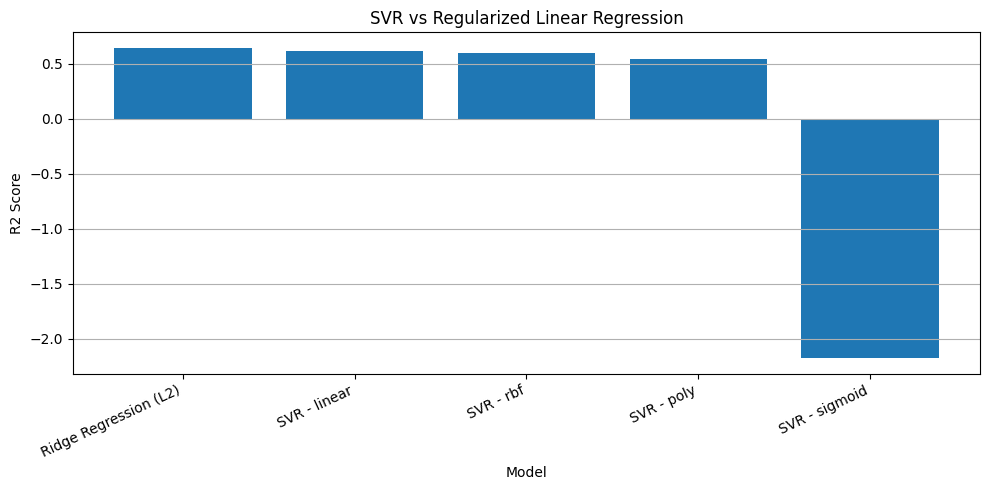

In [49]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparison_p2['Model'],
    comparison_p2['R2']
)

plt.title('SVR vs Regularized Linear Regression')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [50]:
# HW2 Problem 3b - Regularized Linear Regression

from sklearn.preprocessing import MinMaxScaler

# Same 11 features and 80/20 split from HW2
X_train_hw2, X_test_hw2, y_train_hw2, y_test_hw2 = train_test_split(
    X_h, y_h,
    test_size=0.20,
    random_state=42
)

# HW2 used min-max normalization
hw2_scaler = MinMaxScaler()

X_train_hw2 = hw2_scaler.fit_transform(X_train_hw2)
X_test_hw2 = hw2_scaler.transform(X_test_hw2)

# Add bias column
X_train_bias = np.c_[
    np.ones(len(X_train_hw2)),
    X_train_hw2
]

X_test_bias = np.c_[
    np.ones(len(X_test_hw2)),
    X_test_hw2
]

# Original HW2 training settings
learning_rate = 0.05
iterations = 5000
lambda_value = 0.01

theta = np.zeros(X_train_bias.shape[1])
m = len(y_train_hw2)

for i in range(iterations):
    predictions = X_train_bias @ theta
    error = predictions - y_train_hw2.to_numpy()

    gradient = (1 / m) * (X_train_bias.T @ error)

    # L2 regularization, excluding bias
    gradient[1:] += (lambda_value / m) * theta[1:]

    theta = theta - learning_rate * gradient

# Predict housing prices
hw2_predictions = X_test_bias @ theta

print("HW2 regularized model reproduced.")
print("Final parameters:", theta)

HW2 regularized model reproduced.
Final parameters: [1914511.78300134 3419186.62617666  462727.9435163  3291979.62129734
 1268396.45577309  420649.15689088  246971.8164557   431574.25532833
  713386.92511548  810651.69672364  747835.20349442  636496.14208782]


In [51]:
# Evaluate HW2 model using HW4 metrics

hw2_mae = mean_absolute_error(
    y_test_hw2, hw2_predictions
)

hw2_rmse = np.sqrt(
    mean_squared_error(y_test_hw2, hw2_predictions)
)

hw2_r2 = r2_score(
    y_test_hw2, hw2_predictions
)

hw2_loss = mean_squared_error(
    y_test_hw2, hw2_predictions
) / 2

print("HW2 Problem 3b Results")
print("--------------------------")
print(f"MAE: {hw2_mae:.4f}")
print(f"RMSE: {hw2_rmse:.4f}")
print(f"R2: {hw2_r2:.4f}")
print(f"Validation Loss: {hw2_loss:.4f}")

HW2 Problem 3b Results
--------------------------
MAE: 977450.4006
RMSE: 1340712.8460
R2: 0.6444
Validation Loss: 898755467776.3109


HW2 vs HW4 Model Comparison


,Model,MAE,RMSE,R2
0,HW2 Regularized Linear Regression,9.774504e+05,1.340713e+06,0.6444
1,SVR - linear,1.000478e+06,1.389562e+06,0.6180
2,SVR - rbf,1.049355e+06,1.427320e+06,0.5970
3,SVR - poly,1.090739e+06,1.522343e+06,0.5415
4,SVR - sigmoid,2.607715e+06,4.007237e+06,-2.1769


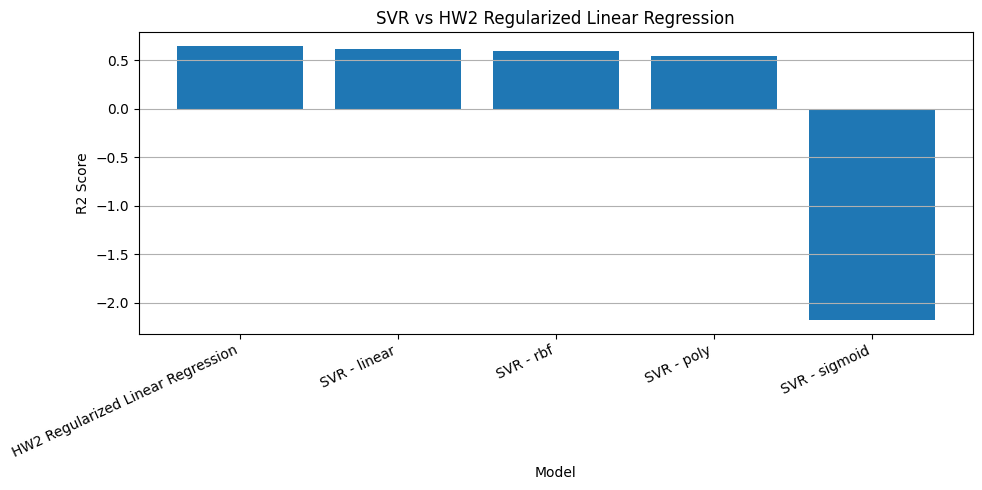

In [52]:
# Compare HW4 SVR models against original HW2 model

hw2_results = {
    'Model': 'HW2 Regularized Linear Regression',
    'MAE': hw2_mae,
    'RMSE': hw2_rmse,
    'R2': hw2_r2
}

comparison_p2 = svr_results_df.copy()

comparison_p2.insert(
    0, 'Model',
    'SVR - ' + comparison_p2['Kernel']
)

comparison_p2 = comparison_p2.drop(columns=['Kernel'])

comparison_p2 = pd.concat([
    pd.DataFrame([hw2_results]),
    comparison_p2
], ignore_index=True)

print("HW2 vs HW4 Model Comparison")
display(comparison_p2.round(4))

plt.figure(figsize=(10, 5))

plt.bar(
    comparison_p2['Model'],
    comparison_p2['R2']
)

plt.title('SVR vs HW2 Regularized Linear Regression')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [54]:
from google.colab import files

uploaded = files.upload()

Saving Noah_Harris_801353171_HW4 (1).ipynb to Noah_Harris_801353171_HW4 (1).ipynb


In [55]:
import os
import subprocess

notebook_name = [
    f for f in uploaded.keys()
    if f.endswith('.ipynb')
][0]

subprocess.run([
    'jupyter',
    'nbconvert',
    '--to', 'html',
    '--embed-images',
    notebook_name
], check=True)

html_name = os.path.splitext(notebook_name)[0] + '.html'

print("HTML conversion complete:", html_name)

HTML conversion complete: Noah_Harris_801353171_HW4 (1).html


In [56]:
files.download(html_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>